# Chapter 6: Statistical Machine Learning

**Book:** Practical Statistics for Data Scientists, Second Edition  
**Authors:** Peter Bruce, Andrew Bruce, and Peter Gedeck

## 1. Introduction to Statistical Machine Learning

Statistical machine learning focuses on developing predictive models that learn patterns from data. These methods are supervised learning techniques because they use observations with known outcomes to predict outcomes for new observations.

Unlike classical statistical models that often impose a specific overall structure on the data, statistical machine learning methods can learn more flexible relationships between predictors and outcomes.

Important methods discussed in this chapter include K-Nearest Neighbors, decision trees, bagging, random forests, and boosting.

### Objectives
- Understand the basic concepts of statistical machine learning.
- Implement K-Nearest Neighbors using Python.
- Build and interpret decision tree models.
- Understand bagging and random forest algorithms.
- Understand boosting and ensemble learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Load classification dataset
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target classes:", data.target_names)

Dataset shape: (569, 30)
Training data: (426, 30)
Testing data: (143, 30)
Target classes: ['malignant' 'benign']


## 2. K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a method that predicts the class or value of an observation by examining similar observations in the training data.

For classification, the algorithm identifies the K nearest observations and assigns the majority class among those neighbors. For regression, it predicts a numerical value by calculating the average of the neighbors' values.

The distance between observations can be measured using Euclidean distance or other distance metrics. Because distance calculations are affected by the scale of the predictor variables, standardization is often necessary.

The choice of K influences model performance. A small K may be sensitive to noise, while a large K may overlook local patterns in the data.

In [2]:
# Create a KNN classifier
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print("KNN ROC AUC:",
      roc_auc_score(y_test, knn_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    knn_pred,
    target_names=data.target_names
))

KNN Accuracy: 0.9790209790209791
KNN ROC AUC: 0.9844863731656185

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



## 3. Tree Models

Tree models, also known as Classification and Regression Trees (CART), predict outcomes by repeatedly dividing data into smaller groups based on predictor variables.

Each split creates a decision rule that separates observations according to a selected feature and threshold. For classification, the algorithm attempts to create groups with more homogeneous class labels.

Decision trees are relatively easy to interpret because their predictions can be explained through a sequence of rules. However, a fully grown tree may overfit the training data by learning noise instead of general patterns.

The complexity of a tree can be controlled using parameters such as maximum depth and minimum samples per leaf.

In [3]:
# Create a decision tree classifier
tree_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tree_pred,
    target_names=data.target_names
))

Decision Tree Accuracy: 0.9300699300699301

Confusion Matrix:
[[48  5]
 [ 5 85]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        53
      benign       0.94      0.94      0.94        90

    accuracy                           0.93       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143



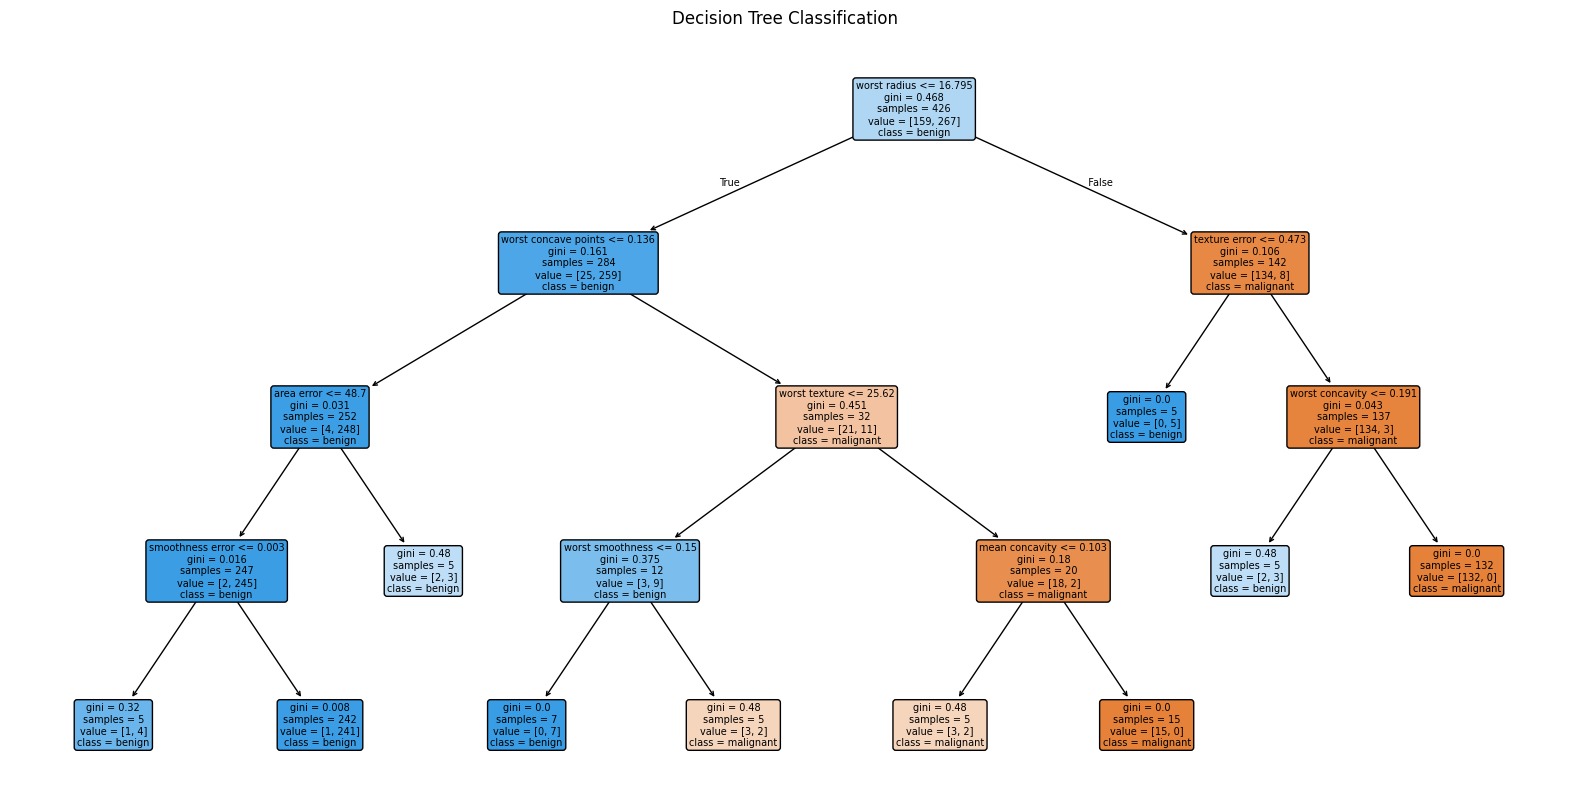

In [4]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=list(X.columns),
    class_names=list(data.target_names),
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Decision Tree Classification")
plt.show()

## 4. Bagging and the Random Forest

Ensemble learning combines predictions from multiple models instead of relying on a single model.

Bagging, or bootstrap aggregating, trains several models using different bootstrap samples of the training data. The resulting predictions are then combined through averaging or majority voting.

Random forest is an ensemble method based on decision trees. In addition to using bootstrap samples, it considers randomly selected subsets of predictor variables when building the trees.

Combining multiple trees can improve prediction stability and reduce the variability associated with an individual decision tree. Random forest can also estimate feature importance to help identify predictors that contribute to the model's predictions.

In [5]:
# Create a random forest classifier
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Random Forest ROC AUC:",
      roc_auc_score(y_test, rf_prob))

print("Out-of-Bag Score:",
      rf_model.oob_score_)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.958041958041958
Random Forest ROC AUC: 0.9942348008385744
Out-of-Bag Score: 0.9624413145539906

Confusion Matrix:
[[49  4]
 [ 2 88]]


Top 10 Important Features:
worst area              0.135029
worst perimeter         0.134587
worst concave points    0.124100
mean concave points     0.096553
worst radius            0.084370
mean perimeter          0.054212
mean radius             0.050475
mean concavity          0.045244
mean area               0.041568
area error              0.032309
dtype: float64


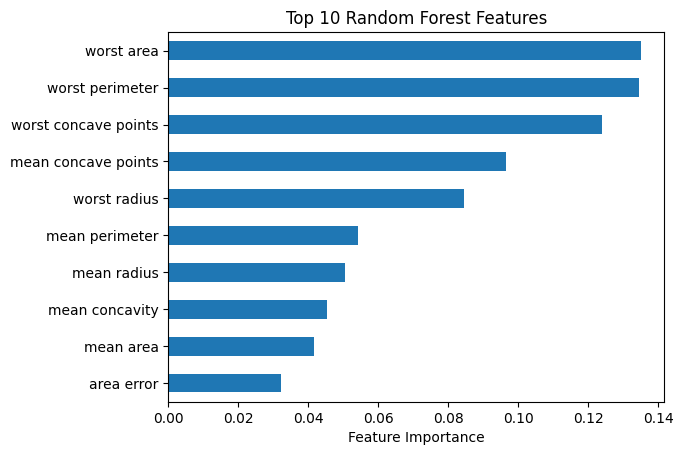

In [6]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Features")
plt.show()

## 5. Boosting

Boosting is an ensemble learning technique that builds a sequence of models. Each successive model attempts to improve the predictions made by the previous models.

Several boosting methods exist, including AdaBoost, gradient boosting, and stochastic gradient boosting. Gradient boosting builds models by optimizing a loss function, while stochastic gradient boosting incorporates sampling of observations and predictors.

Boosting can produce strong predictive performance, but it requires careful selection of hyperparameters. Excessive model complexity can lead to overfitting.

Important hyperparameters include the number of estimators, learning rate, and tree depth.

In [8]:
# Create a gradient boosting classifier
boost_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

# Train the model
boost_model.fit(X_train, y_train)

# Make predictions
boost_pred = boost_model.predict(X_test)
boost_prob = boost_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, boost_pred))

print("Gradient Boosting ROC AUC:",
      roc_auc_score(y_test, boost_prob))

print("\nClassification Report:")
print(classification_report(
    y_test,
    boost_pred,
    target_names=data.target_names
))

Gradient Boosting Accuracy: 0.951048951048951
Gradient Boosting ROC AUC: 0.9930817610062893

Classification Report:
              precision    recall  f1-score   support

   malignant       0.96      0.91      0.93        53
      benign       0.95      0.98      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



## 6. Comparing Machine Learning Models

Different machine learning methods have different strengths and limitations.

K-Nearest Neighbors relies on similarities between observations and is sensitive to feature scaling. Decision trees produce interpretable decision rules but may overfit the training data.

Random forest combines multiple decision trees to improve stability and predictive performance. Boosting builds models sequentially to reduce prediction errors, but its performance depends on appropriate hyperparameter settings.

Model selection should consider predictive accuracy, computational cost, interpretability, and the ability to generalize to unseen observations.

## Summary

Statistical machine learning provides flexible methods for classification and regression.

The main concepts discussed in this chapter are:

- K-Nearest Neighbors predicts outcomes based on similar observations.
- Tree models create decision rules by recursively partitioning data.
- Bagging combines models trained on bootstrap samples.
- Random forest combines multiple randomized decision trees.
- Boosting builds sequential models to improve predictions.

These techniques are important tools for predictive modeling. Their performance should be evaluated using data that was not used during training.

In [9]:
# Compare classification models
results = pd.DataFrame({
    "Model": [
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, boost_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, knn_prob),
        roc_auc_score(
            y_test,
            tree_model.predict_proba(X_test)[:, 1]
        ),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, boost_prob)
    ]
})

print(results.round(4))

                 Model  Accuracy  ROC AUC
0  K-Nearest Neighbors    0.9790   0.9845
1        Decision Tree    0.9301   0.9314
2        Random Forest    0.9580   0.9942
3    Gradient Boosting    0.9510   0.9931
